# Import Libraries

In [1]:
import pandas as pd
import json
import numpy as np
import pickle
from pathlib import Path
from tqdm import tqdm
from textwrap import dedent
from typing import Literal, Mapping, TypedDict
import ast
import mlflow
import mlflow.sklearn
from tqdm import tqdm
from pydantic import BaseModel, ValidationError
from transformers import AutoTokenizer, AutoModelForCausalLM
import transformers

In [2]:
import torch

In [3]:
import boto3
# import wandb

In [4]:
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report,ConfusionMatrixDisplay

# Boto3 Setup

In [5]:
#Check the latest version of boto3

print("boto3 version: ", boto3.__version__)

print("pandas version: ", pd.__version__)
import json
print('json version: ', json.__version__)
from botocore.exceptions import ClientError

region = "us-east-1"

session = boto3.Session(profile_name="AWS_bedrock_NHL")

#Create Bedrock and Bedrock runtime clients
bedrock = session.client("bedrock", region_name=region)
br = session.client("bedrock-runtime", region_name=region)

boto3 version:  1.43.94
pandas version:  2.3.3
json version:  2.0.9


# MLflow Setup

In [6]:
# Configure MLflow to use a local SQLite backend store.
# This will create (or reuse) an "mlflow.db" file in the current working directory.
MLFLOW_DB_PATH = "mlflow.db"

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH}")

print("MLflow tracking URI:", mlflow.get_tracking_uri())


MLflow tracking URI: sqlite:///mlflow.db


# Config

In [8]:
model_id_name_dict  = {'ug3pv3tm0cqj':'amazon-nova-pro-v1-0',
                     'jclyy0txowgp':'mistral-7b-instruct-v0-2', #32k
                      'jfj5rgftsdq5':'meta-llama3-1-70b-instruct-v1-0', #128k
                      'vjs5dyljcm0y':'meta-llama3-1-8b-instruct-v1-0',#32k
                      'uyrecy708aqn':'mixtral-8x7b-instruct-v0-1',
                      'gaawkqvz1uc3': 'anthropic-claude-opus-4-6-v1',
                      'z1q2q8peq81j' : 'claude-haiku-4-5-v1-0',
                      'RB_App':'Rule-Based_Algorithm'}

class config:
    model_id = 'vjs5dyljcm0y'
    model_name = model_id_name_dict[model_id]
    label_mapping = {'positive': 0, 'negative':1, 'unclear':2, 'none':3}
    all_at_once = True

    add_evidence = True

    use_local_model = True
    local_model_path = '/home/shared/Models/Llama-3.1-8B-Instruct/' ### Path where model is downloaded

## Prompt config

In [9]:
class prompt_config:
    all_at_once = """
Your task is to identify social determinants of health (SDOH) information in 12 SDOH domains from a given clinical note and classify each domain using exactly one label from allowed 4 labels. 

Allowed labels: 

DomainName-none = no domain-related information is documented anywhere in the note. 

DomainName-positive = the note explicitly indicates a current social need, barrier, risk, or adverse condition in this domain. 

DomainName-negative = the note explicitly indicates no need/risk in this domain, or documents a stable/adequate condition. 

DomainName-unclear = the note contains domain-related language, but the information is incomplete, ambiguous, neutral, historical only, templated without an interpretable response, or conflicting. 

Core classification rules: 

Use only the text in the note. 

Do not infer a problem unless the note gives direct evidence. 

If the domain is not mentioned at all, assign none. 

If a screening question is mentioned but no patient answer/result is documented, assign unclear. 

If the note clearly documents a present barrier, need, or adverse response, assign positive. 

If the note clearly documents no barrier, no need, or a stable/adequate status, assign negative. 

If the note contains mixed or conflicting statements, use the most current statement when timing is clear; otherwise assign unclear. 

Neutral contextual mentions alone are not enough. For example, “has children,” “lives alone,” “takes the bus,” or “screened for transportation” should usually be unclear unless the note clearly states whether there is a need/risk. 

Historical problems that are clearly resolved should be negative only if the note explicitly states the problem is no longer present; otherwise use unclear. 

Prioritize precision over recall: if evidence is weak, choose unclear rather than positive. 

Domain semantics: 

child_family_care 
This domain covers child care, daycare, dependent care, or difficulty paying for child care. 
Positive examples: needs daycare, cannot afford child care, child care is a barrier. 
Negative examples: no child care needs, child care is adequate, dependent care needs are met. 
Unclear examples: has children, child care discussed, family responsibilities mentioned without stating a need. 

education 
This domain covers educational attainment or education-related disadvantage. 
Positive examples: less than high school diploma, very limited schooling, education level suggests disadvantage. 
Negative examples: high school graduate, GED, or higher education clearly documented. 
Unclear examples: education discussed without a clear level, school history mentioned without enough detail. 
Important: do not treat any mention of school as positive unless low attainment or education-related disadvantage is clearly documented. 

employment 
This domain covers unemployment, job instability, or needing help finding work. 
Positive examples: unemployed and looking for work, wants help finding a job, cannot keep a job. 
Negative examples: employed, stable work, no employment assistance needed. 
Unclear examples: job discussed without clear current status, retired/disability status mentioned without clear employment need. 

financial_strain 
This domain covers difficulty paying for basics such as food, housing, heating, medical care, medications, or other essential expenses. 
Positive examples: somewhat hard or very hard to pay for basics, trouble paying for medicines, cannot afford bills. 
Negative examples: not hard to pay for basics, denies financial concerns, medications are affordable. 
Unclear examples: money concerns mentioned without indicating whether basic needs are affected. 

food_insecurity 
This domain covers worrying food will run out, food actually running out, skipping meals, or not having enough money for food. 
Positive examples: often true/sometimes true that food runs out, household ran out of food, cannot afford food. 
Negative examples: food secure, denies food insecurity, enough food available. 
Unclear examples: appetite issues, diet changes, or nutrition counseling without evidence of access problems. 

housing_instability 
This domain covers unstable housing, homelessness risk, risk of losing housing, eviction risk, or inability to pay rent/mortgage on time. 
Positive examples: worried about losing housing, no steady place to live, unable to pay rent or mortgage on time. 
Negative examples: steady place to live, housing stable, denies housing concerns. 
Unclear examples: housing mentioned without stability status, temporarily staying somewhere but unclear whether this reflects instability. 

housing_quality 
This domain covers unsafe or poor housing conditions. 
Positive examples: pests, bugs, mice, inadequate heat, mold, leaks, unsafe housing conditions. 
Negative examples: home conditions are adequate, safe, or no housing quality problems. 
Unclear examples: housing discussed without condition details. 

relationship_safety 
This domain covers threats, physical harm, abuse, or feeling unsafe with family, friends, partner, or others. 
Positive examples: threatened with harm, physically hurt, abuse, feels unsafe in relationship/home. 
Negative examples: denies abuse, denies violence, feels safe. 
Unclear examples: safety screening mentioned without result, interpersonal conflict mentioned without clear threat/harm. 

social_isolation 
This domain covers loneliness, isolation, or very limited meaningful contact with others. 
Positive examples: feels lonely, feels isolated, sees/talks to close people less than once a week. 
Negative examples: regular supportive contact, denies loneliness or isolation. 
Unclear examples: lives alone, few family details, limited social history without clear loneliness or support deficit. 

stress 
This domain covers clinically meaningful current stress burden. 
Positive examples: stressed, quite a bit of stress, ongoing stress affecting daily life. 
Negative examples: denies stress, no current stress concerns. 
Unclear examples: anxiety/depression history without explicit current stress, stress discussed in general terms only. 
Important: do not classify a psychiatric diagnosis alone as stress unless the note explicitly describes current stress. 

transportation 
This domain covers lack of transportation interfering with medical appointments, medications, work, meetings, or daily living needs. 
Positive examples: transportation kept patient from appointments, trouble getting transportation, unable to get medications because of transportation. 
Negative examples: no transportation problems, reliable transportation, denies transportation barriers. 
Unclear examples: uses bus, relies on family rides, transportation discussed without saying whether it is a barrier. 

utilities 
This domain covers difficulty paying for heating, water, electricity, gas, or risk of shutoff. 
Positive examples: trouble paying utility bills, threatened shutoff, already shut off. 
Negative examples: no utility concerns, utilities are stable and paid. 
Unclear examples: utility assistance discussed without clear need, household bills mentioned without indicating utility risk. 

Output requirements: 
- Use only the text in the note. Do not infer a problem.
- If the domain is not mentioned, assign none.
- If a screening question is documented without a patient answer/result, assign unclear.
- If evidence is weak, choose unclear rather than positive.
- No explanation to be provided. 
- No other text to be included before and after json output.

{evidence_instruction}

Return in this schema and no other text before and after as it will be converted to json using ast.literal_eval(): 

{{
  "child_family_care": {{"label": "<none|positive|negative|unclear>"{evidence_schema_field} }},
  "education": {{"label": "<none|positive|negative|unclear>"{evidence_schema_field} }},
  "employment": {{"label": "<none|positive|negative|unclear>"{evidence_schema_field} }},
  "financial_strain": {{"label": "<none|positive|negative|unclear>"{evidence_schema_field} }},
  "food_insecurity": {{"label": "<none|positive|negative|unclear>"{evidence_schema_field} }},
  "housing_instability": {{"label": "<none|positive|negative|unclear>"{evidence_schema_field} }},
  "housing_quality": {{"label": "<none|positive|negative|unclear>"{evidence_schema_field} }},
  "relationship_safety": {{"label": "<none|positive|negative|unclear>"{evidence_schema_field} }},
  "social_isolation": {{"label": "<none|positive|negative|unclear>"{evidence_schema_field} }},
  "stress": {{"label": "<none|positive|negative|unclear>"{evidence_schema_field} }},
  "transportation": {{"label": "<none|positive|negative|unclear>"{evidence_schema_field} }},
  "utilities": {{"label": "<none|positive|negative|unclear>"{evidence_schema_field} }}
}}

Clinical note: 
{clinical_note}

"""

### Individual ###
    child_family_care = """
    Your task is to identify child and family care social determinants of health (SDOH) information in the clinical note and classify it using exactly one allowed label.
    
    Allowed labels:
    - none = no child/family-care-related information is documented anywhere in the note.
    - positive = the note explicitly indicates a current child care, daycare, dependent care, or child-care-cost need, barrier, or adverse condition.
    - negative = the note explicitly indicates no child care or dependent care need, or that these needs are adequately met.
    - unclear = the note contains child/family-care-related language, but the information is incomplete, ambiguous, neutral, historical only, templated without an interpretable response, or conflicting.
    
    Rules:
    - Use only the text in the note. Do not infer a problem.
    - If the domain is not mentioned, assign none.
    - If a screening question is documented without a patient answer/result, assign unclear.
    - If a current child care barrier or inability to afford care is explicitly documented, assign positive.
    - If child care needs are explicitly denied or documented as adequate, assign negative.
    - Mentions of children, parenting, or family responsibilities alone are unclear unless a child-care need/status is stated.
    - If evidence is weak, choose unclear rather than positive.
    - No explanation to be provided.
    {evidence_instruction}
    Clinical note:
    {clinical_note}
    
    Return this schema and no other text before and after as it will be converted to json using ast.literal_eval():
    {{
      "child_family_care": {{
        "label": "<none|positive|negative|unclear>"{evidence_schema_field}
      }}
    }}
    """
    
    education = """
    Your task is to identify education-related social determinants of health (SDOH) information in the clinical note and classify it using exactly one allowed label.
    
    Allowed labels:
    - none = no education-related information is documented anywhere in the note.
    - positive = the note explicitly documents low educational attainment or an education-related disadvantage, such as less than a high school diploma or very limited schooling.
    - negative = the note explicitly documents a high school diploma, GED, or higher education.
    - unclear = the note contains education-related language, but the level/status is incomplete, ambiguous, neutral, historical only, templated without an interpretable response, or conflicting.
    
    Rules:
    - Use only the text in the note. Do not infer a problem.
    - If education is not mentioned, assign none.
    - If a screening question is documented without a patient answer/result, assign unclear.
    - Do not treat any mention of school as positive unless low attainment or education-related disadvantage is clearly documented.
    - School history without a clear attainment level is unclear.
    - If evidence is weak, choose unclear rather than positive.
    - No explanation to be provided.
    {evidence_instruction}
    Clinical note:
    {clinical_note}
    
    Return this schema and no other text before and after as it will be converted to json using ast.literal_eval():
    {{
      "education": {{
        "label": "<none|positive|negative|unclear>"{evidence_schema_field}
      }}
    }} 
    """
    
    employment = """
    Your task is to identify employment-related social determinants of health (SDOH) information in the clinical note and classify it using exactly one allowed label.
    
    Allowed labels:
    - none = no employment-related information is documented anywhere in the note.
    - positive = the note explicitly indicates unemployment, job instability, inability to keep a job, or a current need for help finding work.
    - negative = the note explicitly documents employment, stable work, or no need for employment assistance.
    - unclear = the note contains employment-related language, but current status/need is incomplete, ambiguous, neutral, historical only, templated without an interpretable response, or conflicting.
    
    Rules:
    - Use only the text in the note. Do not infer a problem.
    - If employment is not mentioned, assign none.
    - If a screening question is documented without a patient answer/result, assign unclear.
    - Retired status, disability status, or a job discussion without a clear employment need/status is unclear.
    - If evidence is weak, choose unclear rather than positive.
    - No explanation to be provided.
    {evidence_instruction}
    Clinical note:
    {clinical_note}
    
   Return this schema and no other text before and after as it will be converted to json using ast.literal_eval():
    
    {{
      "employment": {{
        "label": "<none|positive|negative|unclear>"{evidence_schema_field}
      }}
    }}
    """
    
    financial_strain = """
    Your task is to identify financial-strain social determinants of health (SDOH) information in the clinical note and classify it using exactly one allowed label.
    
    Allowed labels:
    - none = no financial-strain-related information is documented anywhere in the note.
    - positive = the note explicitly indicates difficulty paying for basics or essential expenses, including food, housing, heating, medical care, medications, bills, rent, or mortgage.
    - negative = the note explicitly indicates no financial concerns, that it is not hard to pay for basics, or that medications/essential needs are affordable.
    - unclear = the note contains financial language, but the information is incomplete, ambiguous, neutral, historical only, templated without an interpretable response, or conflicting.
    
    Rules:
    - Use only the text in the note. Do not infer a problem.
    - If financial strain is not mentioned, assign none.
    - If a screening question is documented without a patient answer/result, assign unclear.
    - General money concerns without evidence that basic needs or essential expenses are affected are unclear.
    - If evidence is weak, choose unclear rather than positive.
    - No explanation to be provided.
    {evidence_instruction}
    Clinical note:
    {clinical_note}
    
   Return this schema and no other text before and after as it will be converted to json using ast.literal_eval():
    {{
      "financial_strain": {{
        "label": "<none|positive|negative|unclear>"{evidence_schema_field}
      }}
    }}
    """
    
    food_insecurity = """
    Your task is to identify food-insecurity social determinants of health (SDOH) information in the clinical note and classify it using exactly one allowed label.
    
    Allowed labels:
    - none = no food-insecurity-related information is documented anywhere in the note.
    - positive = the note explicitly indicates worry that food will run out, food running out, skipped meals, inadequate food, or inability to afford food.
    - negative = the note explicitly indicates food security, enough food available, or denial of food insecurity.
    - unclear = the note contains food- or nutrition-related language, but the information is incomplete, ambiguous, neutral, historical only, templated without an interpretable response, or conflicting.
    
    Rules:
    - Use only the text in the note. Do not infer a problem.
    - If food insecurity is not mentioned, assign none.
    - If a screening question is documented without a patient answer/result, assign unclear.
    - Appetite changes, diet changes, nutrition counseling, or weight concerns alone are unclear unless food access is addressed.
    - If evidence is weak, choose unclear rather than positive.
    - No explanation to be provided.
    {evidence_instruction}
    Clinical note:
    {clinical_note}
    
    Return this schema and no other text before and after as it will be converted to json using ast.literal_eval():
    {{
      "food_insecurity": {{
        "label": "<none|positive|negative|unclear>"{evidence_schema_field}
      }}
    }}
    """
    
    housing_instability = """
    Your task is to identify housing-instability social determinants of health (SDOH) information in the clinical note and classify it using exactly one allowed label.
    
    Allowed labels:
    - none = no housing-stability-related information is documented anywhere in the note.
    - positive = the note explicitly indicates homelessness, lack of a steady place to live, risk of losing housing, eviction risk, or inability to pay rent or mortgage on time.
    - negative = the note explicitly indicates stable housing, a steady place to live, or no housing concerns.
    - unclear = the note contains housing-related language, but stability status is incomplete, ambiguous, neutral, historical only, templated without an interpretable response, or conflicting.
    
    Rules:
    - Use only the text in the note. Do not infer a problem.
    - If housing stability is not mentioned, assign none.
    - If a screening question is documented without a patient answer/result, assign unclear.
    - Temporarily staying with someone is unclear unless the note explicitly establishes housing instability or stable housing.
    - Housing conditions such as pests or mold belong to housing quality, not this domain.
    - If evidence is weak, choose unclear rather than positive.
    - No explanation to be provided.
    {evidence_instruction}
    Clinical note:
    {clinical_note}
    
    Return this schema and no other text before and after as it will be converted to json using ast.literal_eval():
    {{
      "housing_instability": {{
        "label": "<none|positive|negative|unclear>"{evidence_schema_field}
      }}
    }}
    """
    
    housing_quality = """
    Your task is to identify housing-quality social determinants of health (SDOH) information in the clinical note and classify it using exactly one allowed label.
    
    Allowed labels:
    - none = no housing-quality-related information is documented anywhere in the note.
    - positive = the note explicitly indicates unsafe or poor home conditions, including pests, bugs, mice, mold, leaks, inadequate heat, or other unsafe conditions.
    - negative = the note explicitly indicates that home conditions are safe, adequate, or free from housing-quality problems.
    - unclear = the note contains housing-related language, but condition details are incomplete, ambiguous, neutral, historical only, templated without an interpretable response, or conflicting.
    
    Rules:
    - Use only the text in the note. Do not infer a problem.
    - If housing quality is not mentioned, assign none.
    - If a screening question is documented without a patient answer/result, assign unclear.
    - Housing status without condition details is unclear for this domain.
    - Housing instability, eviction risk, and homelessness belong to housing_instability, not this domain.
    - If evidence is weak, choose unclear rather than positive.
    - No explanation to be provided.
    {evidence_instruction}
    Clinical note:
    {clinical_note}
    
    Return this schema and no other text before and after as it will be converted to json using ast.literal_eval():
    {{
      "housing_quality": {{
        "label": "<none|positive|negative|unclear>"{evidence_schema_field}
      }}
    }}
    """
    
    relationship_safety = """
    Your task is to identify relationship-safety social determinants of health (SDOH) information in the clinical note and classify it using exactly one allowed label.
    
    Allowed labels:
    - none = no relationship-safety-related information is documented anywhere in the note.
    - positive = the note explicitly indicates threats, physical harm, abuse, violence, coercion, or feeling unsafe with a partner, family member, friend, or another person.
    - negative = the note explicitly denies abuse or violence, or states that the patient feels safe.
    - unclear = the note contains safety- or relationship-related language, but the information is incomplete, ambiguous, neutral, historical only, templated without an interpretable response, or conflicting.
    
    Rules:
    - Use only the text in the note. Do not infer a problem.
    - If relationship safety is not mentioned, assign none.
    - If a screening question is documented without a patient answer/result, assign unclear.
    - Interpersonal conflict alone is unclear unless threat, harm, abuse, violence, or safety concerns are explicitly stated.
    - If evidence is weak, choose unclear rather than positive.
    - No explanation to be provided.
    {evidence_instruction}
    Clinical note:
    {clinical_note}
    
    Return this schema and no other text before and after as it will be converted to json using ast.literal_eval():
    {{
      "relationship_safety": {{
        "label": "<none|positive|negative|unclear>"{evidence_schema_field}
      }}
    }}
    """
    
    social_isolation = """
    Your task is to identify social-isolation social determinants of health (SDOH) information in the clinical note and classify it using exactly one allowed label.
    
    Allowed labels:
    - none = no social-isolation-related information is documented anywhere in the note.
    - positive = the note explicitly indicates loneliness, isolation, or very limited meaningful contact with others, such as seeing or talking to close people less than once per week.
    - negative = the note explicitly indicates regular supportive contact or denies loneliness or isolation.
    - unclear = the note contains social-history or living-situation language, but the information is incomplete, ambiguous, neutral, historical only, templated without an interpretable response, or conflicting.
    
    Rules:
    - Use only the text in the note. Do not infer a problem.
    - If social isolation is not mentioned, assign none.
    - If a screening question is documented without a patient answer/result, assign unclear.
    - Living alone, limited family details, or general social history alone is unclear unless loneliness, isolation, or support frequency is stated.
    - If evidence is weak, choose unclear rather than positive.
    - No explanation to be provided.
    {evidence_instruction}
    Clinical note:
    {clinical_note}
    
    Return this schema and no other text before and after as it will be converted to json using ast.literal_eval():
    {{
      "social_isolation": {{
        "label": "<none|positive|negative|unclear>"{evidence_schema_field}
      }}
    }}
    """
    
    stress = """
    Your task is to identify stress-related social determinants of health (SDOH) information in the clinical note and classify it using exactly one allowed label.
    
    Allowed labels:
    - none = no stress-related information is documented anywhere in the note.
    - positive = the note explicitly indicates current clinically meaningful stress, including feeling stressed or ongoing stress affecting daily life.
    - negative = the note explicitly denies current stress or states there are no current stress concerns.
    - unclear = the note contains mental-health or stress-related language, but the information is incomplete, ambiguous, neutral, historical only, templated without an interpretable response, or conflicting.
    
    Rules:
    - Use only the text in the note. Do not infer a problem.
    - If stress is not mentioned, assign none.
    - If a screening question is documented without a patient answer/result, assign unclear.
    - Do not classify a psychiatric diagnosis, anxiety, or depression alone as stress unless current stress is explicitly described.
    - If evidence is weak, choose unclear rather than positive.
    - No explanation to be provided.
    {evidence_instruction}
    Clinical note:
    {clinical_note}
    
    Return this schema and no other text before and after as it will be converted to json using ast.literal_eval():
    {{
      "stress": {{
        "label": "<none|positive|negative|unclear>"{evidence_schema_field}
      }}
    }}
    """
    
    transportation = """
    Your task is to identify transportation-related social determinants of health (SDOH) information in the clinical note and classify it using exactly one allowed label.
    
    Allowed labels:
    - none = no transportation-related information is documented anywhere in the note.
    - positive = the note explicitly indicates lack of transportation or transportation difficulty interfering with appointments, medications, work, meetings, or daily living needs.
    - negative = the note explicitly indicates reliable transportation or denies transportation barriers.
    - unclear = the note contains transportation-related text, but the information is incomplete, ambiguous, neutral, historical only, templated without an interpretable response, or conflicting.
    
    Rules:
    - Use only the text in the note. Do not infer a problem.
    - If transportation is not mentioned, assign none.
    - If a screening question is documented without a patient answer/result, assign unclear.
    - Using a bus, relying on family rides, or discussing transportation without stating whether it is a barrier is unclear.
    - If evidence is weak, choose unclear rather than positive.
    - No explanation to be provided.
    {evidence_instruction}
    Clinical note:
    {clinical_note}
    
    Return JSON only and no other text as it will be converted to json using ast.literal_eval():
    {{
      "transportation": {{
        "label": "<none|positive|negative|unclear>"{evidence_schema_field}
      }}
    }}
    """
    
    utilities = """
    Your task is to identify utilities-related social determinants of health (SDOH) information in the clinical note and classify it using exactly one allowed label.
    
    Allowed labels:
    - none = no utilities-related information is documented anywhere in the note.
    - positive = the note explicitly indicates difficulty paying for heating, water, electricity, gas, or other utilities, including a threatened or actual shutoff.
    - negative = the note explicitly indicates no utility concerns or that utility bills are stable and paid.
    - unclear = the note contains utilities-related language, but the information is incomplete, ambiguous, neutral, historical only, templated without an interpretable response, or conflicting.
    
    Rules:
    - Use only the text in the note. Do not infer a problem.
    - If utilities are not mentioned, assign none.
    - If a screening question is documented without a patient answer/result, assign unclear.
    - Utility assistance being discussed without a clear documented need is unclear.
    - General household bills without a specific utility-payment problem are unclear.
    - If evidence is weak, choose unclear rather than positive.
    - No explanation to be provided.
    {evidence_instruction}
    Clinical note:
    {clinical_note}
    
    Return this schema and no other text before and after as it will be converted to json using ast.literal_eval():
    {{
      "utilities": {{
        "label": "<none|positive|negative|unclear>"{evidence_schema_field}
      }}
    }}
    """


In [10]:
print(prompt_config.child_family_care)


    Your task is to identify child and family care social determinants of health (SDOH) information in the clinical note and classify it using exactly one allowed label.

    Allowed labels:
    - none = no child/family-care-related information is documented anywhere in the note.
    - positive = the note explicitly indicates a current child care, daycare, dependent care, or child-care-cost need, barrier, or adverse condition.
    - negative = the note explicitly indicates no child care or dependent care need, or that these needs are adequately met.
    - unclear = the note contains child/family-care-related language, but the information is incomplete, ambiguous, neutral, historical only, templated without an interpretable response, or conflicting.

    Rules:
    - Use only the text in the note. Do not infer a problem.
    - If the domain is not mentioned, assign none.
    - If a screening question is documented without a patient answer/result, assign unclear.
    - If a current chil

# Helper Functions

In [12]:
def build_prompt(cli_note, prompt = None):
    assert prompt is not None, "prompt cannot be none"

    if getattr(config, "add_evidence", False):
        evidence_instruction = (
            "Evidence requirement:\n\n"
            "For every domain, also include an \"evidence\" field in the JSON output. "
            "If the label is positive, negative, or unclear, copy the exact verbatim span(s) "
            "from the clinical note that justify the assigned label into the evidence field. "
            "Use the note's own wording; do not paraphrase, summarize, or add information that "
            "is not in the note. If the label is none, set evidence to an empty string \"\"."
        )
        evidence_schema_field = ', "evidence": "<verbatim text from the clinical note, or empty string if label is none>"'
    else:
        evidence_instruction = ""
        evidence_schema_field = ""

    return prompt.format(
        clinical_note = cli_note,
        evidence_instruction = evidence_instruction,
        evidence_schema_field = evidence_schema_field,
    )

In [13]:
local_pipeline = None


def load_local_model():
    global local_pipeline

    if local_pipeline is not None:
        return

    local_model_path = config.local_model_path

    if torch.cuda.is_available():
        dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
        device_map = "auto"
    else:
        dtype = torch.float32
        device_map = None

    print("dtype", dtype)

    local_pipeline = transformers.pipeline(
        task="text-generation",
        model=local_model_path,
        tokenizer=local_model_path,
        model_kwargs={
            "torch_dtype": dtype,
            "low_cpu_mem_usage": True,
        },
        device_map=device_map,
    )


def run_prompt(prompt_text, model_id = config.model_id):

    if config.use_local_model:
        load_local_model()

        messages = [
            {
                "role": "user",
                "content": prompt_text,
            }
        ]

        if getattr(config, "add_evidence", False):
            max_tokens = 700 if getattr(config, "all_at_once", False) else 250
        else:
            max_tokens = 175

        with torch.inference_mode():
            outputs = local_pipeline(
                messages,
                max_new_tokens=max_tokens,
                do_sample=False,
                temperature=None,
                top_p=None,
                pad_token_id=local_pipeline.tokenizer.eos_token_id,
                eos_token_id=local_pipeline.tokenizer.eos_token_id,
            )

        generated = outputs[0]["generated_text"]

        # For chat input, recent Transformers versions return a message list:
        # [
        #   {"role": "user", "content": "..."},
        #   {"role": "assistant", "content": "..."}
        # ]
        if isinstance(generated, list):
            result_text = generated[-1]["content"].strip()
        else:
            # Fallback for older Transformers versions or non-chat output.
            result_text = generated.strip()

    else:
        llm_model_id = f"arn:aws:bedrock:us-east-1:752168372872:application-inference-profile/{model_id}"
        conversation = [
                {
                    "role": "user",
                    "content": [{"text": prompt_text}]
                }
            ]
    
        # Evidence spans make the JSON output longer, especially in all_at_once mode
        # where all 12 domains are returned in a single response.
        if getattr(config, "add_evidence", False):
            max_tokens = 700 if getattr(config, "all_at_once", False) else 250
        else:
            max_tokens = 175
    
        response = br.converse(
                        modelId=llm_model_id,
                        messages=conversation,
                        inferenceConfig={"maxTokens": max_tokens, "temperature": 0.0},
                    )
        result_text = response["output"]["message"]["content"][0]["text"]
    return result_text

In [14]:
def convert_to_labels(data):
    return [config.label_map[item["label"]] for item in data.values()]
    

In [15]:
import ast
import re
from typing import Any

def extract_schema_dict(text: str) -> dict[str, Any]:
    """
    Extract a JSON/Python-dict-like object from surrounding LLM text
    and safely parse it into a Python dictionary.
    """
    match = re.search(r"(\{.*\})", text, flags=re.DOTALL)

    if not match:
        raise ValueError("No brace-delimited dictionary found in text.")

    extracted = match.group(1)
    return extracted
    

In [16]:
print(build_prompt('asdsad', prompt = prompt_config.all_at_once))


Your task is to identify social determinants of health (SDOH) information in 12 SDOH domains from a given clinical note and classify each domain using exactly one label from allowed 4 labels. 

Allowed labels: 

DomainName-none = no domain-related information is documented anywhere in the note. 

DomainName-positive = the note explicitly indicates a current social need, barrier, risk, or adverse condition in this domain. 

DomainName-negative = the note explicitly indicates no need/risk in this domain, or documents a stable/adequate condition. 

DomainName-unclear = the note contains domain-related language, but the information is incomplete, ambiguous, neutral, historical only, templated without an interpretable response, or conflicting. 

Core classification rules: 

Use only the text in the note. 

Do not infer a problem unless the note gives direct evidence. 

If the domain is not mentioned at all, assign none. 

If a screening question is mentioned but no patient answer/result is

# Data

In [17]:
input_dir = Path("synthetic_data")

dataset_order = [
    "child_family_care",
    "education",
    "employment",
    "financial_strain",
    "food_insecurity",
    "housing_instability",
    "housing_quality",
    "relationship_safety",
    "social_isolation",
    "stress",
    "transportation",
    "utilities",
]

loaded_datasets_pos = {}

for dataset_name in dataset_order:
    pkl_path = input_dir / f"{dataset_name}_syn_data_pos.pkl"

    if not pkl_path.exists():
        print(f"Warning: file not found: {pkl_path}")
        continue

    with open(pkl_path, "rb") as f:
        loaded_datasets_pos[f"{dataset_name}_syn_data_pos"] = pickle.load(f)

    print(f"Loaded: {pkl_path}")

print(len(loaded_datasets_pos))

Loaded: synthetic_data/child_family_care_syn_data_pos.pkl
Loaded: synthetic_data/education_syn_data_pos.pkl
Loaded: synthetic_data/employment_syn_data_pos.pkl
Loaded: synthetic_data/financial_strain_syn_data_pos.pkl
Loaded: synthetic_data/food_insecurity_syn_data_pos.pkl
Loaded: synthetic_data/housing_instability_syn_data_pos.pkl
Loaded: synthetic_data/housing_quality_syn_data_pos.pkl
Loaded: synthetic_data/relationship_safety_syn_data_pos.pkl
Loaded: synthetic_data/social_isolation_syn_data_pos.pkl
Loaded: synthetic_data/stress_syn_data_pos.pkl
Loaded: synthetic_data/transportation_syn_data_pos.pkl
Loaded: synthetic_data/utilities_syn_data_pos.pkl
12


In [18]:
# Negative samples
input_dir = Path("synthetic_data")

dataset_order = [
    "child_family_care",
    "education",
    "employment",
    "financial_strain",
    "food_insecurity",
    "housing_instability",
    "housing_quality",
    "relationship_safety",
    "social_isolation",
    "stress",
    "transportation",
    "utilities",
]

loaded_datasets_neg = {}

for dataset_name in dataset_order:
    pkl_path = input_dir / f"{dataset_name}_syn_data_neg.pkl"

    if not pkl_path.exists():
        print(f"Warning: file not found: {pkl_path}")
        continue

    with open(pkl_path, "rb") as f:
        loaded_datasets_neg[f"{dataset_name}_syn_data_neg"] = pickle.load(f)

    print(f"Loaded: {pkl_path}")

print(f"\nNumber of negative datasets loaded: {len(loaded_datasets_neg)}")
print("Dataset order:", list(loaded_datasets_neg.keys()))

Loaded: synthetic_data/child_family_care_syn_data_neg.pkl
Loaded: synthetic_data/education_syn_data_neg.pkl
Loaded: synthetic_data/employment_syn_data_neg.pkl
Loaded: synthetic_data/financial_strain_syn_data_neg.pkl
Loaded: synthetic_data/food_insecurity_syn_data_neg.pkl
Loaded: synthetic_data/housing_instability_syn_data_neg.pkl
Loaded: synthetic_data/housing_quality_syn_data_neg.pkl
Loaded: synthetic_data/relationship_safety_syn_data_neg.pkl
Loaded: synthetic_data/social_isolation_syn_data_neg.pkl
Loaded: synthetic_data/stress_syn_data_neg.pkl
Loaded: synthetic_data/transportation_syn_data_neg.pkl
Loaded: synthetic_data/utilities_syn_data_neg.pkl

Number of negative datasets loaded: 12
Dataset order: ['child_family_care_syn_data_neg', 'education_syn_data_neg', 'employment_syn_data_neg', 'financial_strain_syn_data_neg', 'food_insecurity_syn_data_neg', 'housing_instability_syn_data_neg', 'housing_quality_syn_data_neg', 'relationship_safety_syn_data_neg', 'social_isolation_syn_data_neg'

In [19]:
# Unclear samples
input_dir = Path("synthetic_data")

dataset_order = [
    "child_family_care",
    "education",
    "employment",
    "financial_strain",
    "food_insecurity",
    "housing_instability",
    "housing_quality",
    "relationship_safety",
    "social_isolation",
    "stress",
    "transportation",
    "utilities",
]

loaded_datasets_unclear = {}

for dataset_name in dataset_order:
    pkl_path = input_dir / f"{dataset_name}_syn_data_unclear.pkl"

    if not pkl_path.exists():
        print(f"Warning: file not found: {pkl_path}")
        continue

    with open(pkl_path, "rb") as f:
        loaded_datasets_unclear[f"{dataset_name}_syn_data_unclear"] = pickle.load(f)

    print(f"Loaded: {pkl_path}")

print(f"\nNumber of negative datasets loaded: {len(loaded_datasets_unclear)}")
print("Dataset order:", list(loaded_datasets_unclear.keys()))

Loaded: synthetic_data/child_family_care_syn_data_unclear.pkl
Loaded: synthetic_data/education_syn_data_unclear.pkl
Loaded: synthetic_data/employment_syn_data_unclear.pkl
Loaded: synthetic_data/financial_strain_syn_data_unclear.pkl
Loaded: synthetic_data/food_insecurity_syn_data_unclear.pkl
Loaded: synthetic_data/housing_instability_syn_data_unclear.pkl
Loaded: synthetic_data/housing_quality_syn_data_unclear.pkl
Loaded: synthetic_data/relationship_safety_syn_data_unclear.pkl
Loaded: synthetic_data/social_isolation_syn_data_unclear.pkl
Loaded: synthetic_data/stress_syn_data_unclear.pkl
Loaded: synthetic_data/transportation_syn_data_unclear.pkl
Loaded: synthetic_data/utilities_syn_data_unclear.pkl

Number of negative datasets loaded: 12
Dataset order: ['child_family_care_syn_data_unclear', 'education_syn_data_unclear', 'employment_syn_data_unclear', 'financial_strain_syn_data_unclear', 'food_insecurity_syn_data_unclear', 'housing_instability_syn_data_unclear', 'housing_quality_syn_data_u

# Evaluate

In [20]:
print(loaded_datasets_pos['child_family_care_syn_data_pos'][0])

Social Work Note: Patient is a single parent of three children under age 6. Reports significant difficulty finding reliable child care, which has interfered with attending medical appointments. Discussed community daycare resources and referral to local child care assistance program. Will follow up next visit.


In [21]:
print(run_prompt(build_prompt(loaded_datasets_pos['child_family_care_syn_data_pos'][0], prompt = prompt_config.all_at_once)))

dtype torch.float32


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'top_p', 'temperature', 'pad_token_id', 'do_sample', 'max_new_tokens', 'eos_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to forc

Here is the output in the required schema:

{
  "child_family_care": {"label": "positive", "evidence": "Reports significant difficulty finding reliable child care, which has interfered with attending medical appointments." },
  "education": {"label": "none", "evidence": "" },
  "employment": {"label": "none", "evidence": "" },
  "financial_strain": {"label": "none", "evidence": "" },
  "food_insecurity": {"label": "none", "evidence": "" },
  "housing_instability": {"label": "none", "evidence": "" },
  "housing_quality": {"label": "none", "evidence": "" },
  "relationship_safety": {"label": "none", "evidence": "" },
  "social_isolation": {"label": "none", "evidence": "" },
  "stress": {"label": "none", "evidence": "" },
  "transportation": {"label": "none", "evidence": "" },
  "utilities": {"label": "none", "evidence": "" }
}


In [ ]:
sample = extract_schema_dict(run_prompt(build_prompt(loaded_datasets_pos['child_family_care_syn_data_pos'][1], prompt = prompt_config.all_at_once)))

In [ ]:
print(sample)

In [ ]:
ast.literal_eval(sample)

In [ ]:
sample.keys()

In [ ]:
label_ints = [config.label_mapping[item["label"]] for item in sample.values()]
label_ints

In [ ]:
sample = ast.literal_eval(run_prompt(build_prompt(loaded_datasets_pos['child_family_care_syn_data_pos'][1], prompt = prompt_config.transportation)))

In [ ]:
sample

# SDoH Prompt

In [18]:
sdoh_prompts = {
    "child_family_care": prompt_config.child_family_care,
    "education": prompt_config.education,
    "employment": prompt_config.employment,
    "employment": prompt_config.employment,
    "financial_strain": prompt_config.financial_strain,
    "food_insecurity": prompt_config.food_insecurity,
    "housing_instability": prompt_config.housing_instability,
    "housing_quality": prompt_config.housing_quality,
    "relationship_safety": prompt_config.relationship_safety,
    "social_isolation": prompt_config.social_isolation,
    "stress": prompt_config.stress,
    "transportation": prompt_config.transportation,
    "utilities": prompt_config.utilities,
}

In [ ]:
# run_name_prompt = None

# if config.all_at_once:
#     run_name_prompt = 'AllAtOnce'

# if config.all_at_once and config.ev:
#     run_name_prompt = 'AllAtOnce'


## Positive examples

In [36]:
# Create a dedicated MLflow experiment + run for the "positive examples" evaluation
POS_EXPERIMENT_NAME = "SDOH_Positive_Examples_Evaluation"
POS_RUN_NAME = f"positive_examples_{'OneDomain' if not config.all_at_once else 'AllAtOnce'}{'WithEvidence' if config.add_evidence else ''}_run_{config.model_name}_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}"

mlflow.set_experiment(POS_EXPERIMENT_NAME)
pos_run = mlflow.start_run(run_name=POS_RUN_NAME)

print("Experiment name:", POS_EXPERIMENT_NAME)
print("Run name:", POS_RUN_NAME)
print("Run ID:", pos_run.info.run_id)

mlflow.log_param("model_id", getattr(config, "model_id", None))
mlflow.log_param("prompt_strategy", "all_at_once" if config.all_at_once else "per_domain")
mlflow.log_param("num_pos_datasets", len(loaded_datasets_pos))


Experiment name: SDOH_Positive_Examples_Evaluation
Run name: positive_examples_AllAtOnceWithEvidence_run_meta-llama3-1-8b-instruct-v1-0_20260915_160855
Run ID: e037e73d63d0469ab02584b012685c5b


12

In [37]:
def create_gt_pos_label(idx, val = None):
    assert val is not None, "val cannot be none"
    gt = [3]*12
    gt[idx]= val
    return gt
    

In [38]:
config.all_at_once

True

In [40]:
all_gt_labels = []
all_model_lables = []
all_text_outs = []
all_prompts = []

for label_idx, (key,items) in enumerate(tqdm(loaded_datasets_pos.items())):
    print(key)
    for note in tqdm(items):
        
        gt_label = create_gt_pos_label(label_idx,val = 0)
        if config.all_at_once:
            try:
                out = run_prompt(build_prompt(note, prompt = prompt_config.all_at_once))
                label_json = ast.literal_eval(extract_schema_dict(out))
                prediction_label = [config.label_mapping[item["label"]] for item in label_json.values()]
                all_text_outs.append(out)
                all_prompts.append(build_prompt(note, prompt = prompt_config.all_at_once))
            except:
                    print(out)
                    print("#####")
                    print(build_prompt(note, prompt = prompt_config.all_at_once))
                    print("####")
                    print(note)
                    print(asd)
                
        else:
            each_note_label = []
            for key, prompt in sdoh_prompts.items():
                try:
                    out = run_prompt(build_prompt(note, prompt = prompt))
                    each_note_label.append(ast.literal_eval(out))
                    all_text_outs.append(out)
                    all_prompts.append(build_prompt(note, prompt = prompt))
                except:
                    print(out)
                    print("#####")
                    print(build_prompt(note, prompt = prompt))
                    print("####")
                    print(note)
            dict_labels = {key: value for item in json.loads(json.dumps(each_note_label, indent=2)) for key, value in item.items()}
            prediction_label = [config.label_mapping[item["label"]] for item in dict_labels.values()]
            

        all_gt_labels.append(gt_label)
        all_model_lables.append(prediction_label)


# Log basic run info to MLflow
mlflow.log_metric("num_examples_evaluated", len(all_gt_labels))


  0%|                                                   | 0/12 [00:00<?, ?it/s]

child_family_care_syn_data_pos



  0%|                                                    | 0/5 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

 20%|████████▊                                   | 1/5 [00:09<00:39,  9.78s/it][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

 40%|█████████████████▌                          | 2/5 [00:20<00:30, 10.12s/it][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/

education_syn_data_pos



  0%|                                                    | 0/5 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

 20%|████████▊                                   | 1/5 [00:09<00:36,  9.20s/it][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

 40%|█████████████████▌                          | 2/5 [00:18<00:27,  9.30s/it][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/

...


  0%|                                                    | 0/5 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

 20%|████████▊                                   | 1/5 [00:09<00:38,  9.60s/it][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

 40%|█████████████████▌                          | 2/5 [00:19<00:28,  9.63s/it][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/

transportation_syn_data_pos



  0%|                                                    | 0/5 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

 20%|████████▊                                   | 1/5 [00:09<00:38,  9.55s/it][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

 40%|█████████████████▌                          | 2/5 [00:19<00:30, 10.05s/it][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/

utilities_syn_data_pos



  0%|                                                    | 0/5 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

 20%|████████▊                                   | 1/5 [00:11<00:44, 11.13s/it][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

 40%|█████████████████▌                          | 2/5 [00:21<00:32, 10.70s/it][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/

In [ ]:
all_model_lables[0]

In [ ]:
all_text_outs[0]

In [ ]:
loaded_datasets_pos['child_family_care_syn_data_pos'][0]

In [ ]:
for i in all_model_lables:
    if len(i)!=12:
        print(i)

In [ ]:
all_model_lables[0]

In [ ]:
from itertools import chain
all_notes = list(chain.from_iterable(list(loaded_datasets_pos.values())))

for i in range(len(all_model_lables)):
    if all_model_lables[i] != all_gt_labels[i]:
        print("Model label: ", all_model_lables[i])
        print("GT label: :", all_gt_labels[i])

        print("Note:", all_notes[i])
        print("\n\n\n")
        


In [ ]:
    # "child_family_care",
    # "education",
    # "employment",
    # "financial_strain",
    # "food_insecurity",
    # "housing_instability",
    # "housing_quality",
    # "relationship_safety",
    # "social_isolation",
    # "stress",
    # "transportation",
    # "utilities",

In [41]:
y_pred = np.asarray(all_model_lables).ravel()  # fix spelling: labels, not lables
y_true = np.asarray(all_gt_labels).ravel()

assert y_true.shape == y_pred.shape
assert set(np.unique(y_true)).issubset({0, 1, 2, 3})
assert set(np.unique(y_pred)).issubset({0, 1, 2, 3})

report_dict = classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
    target_names=["Positive", "Negative", "Unclear", "None"],
    zero_division=0,
    digits=4,
    output_dict=True,
)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=["Positive", "Negative", "Unclear", "None"],
        zero_division=0,
        digits=4,
))

# Log the classification report to MLflow (as a JSON artifact + per-class metrics)
mlflow.log_dict(report_dict, "positive_examples_classification_report.json")

for cls_name, metrics_dict in report_dict.items():
    if isinstance(metrics_dict, dict):
        safe_name = cls_name.replace(" ", "_")
        for metric_name, metric_value in metrics_dict.items():
            mlflow.log_metric(f"{safe_name}_{metric_name}", metric_value)
    else:
        mlflow.log_metric(cls_name, metrics_dict)


              precision    recall  f1-score   support

    Positive     0.7342    0.9667    0.8345        60
    Negative     0.0000    0.0000    0.0000         0
     Unclear     0.0000    0.0000    0.0000         0
        None     1.0000    0.9667    0.9831       660

    accuracy                         0.9667       720
   macro avg     0.4335    0.4833    0.4544       720
weighted avg     0.9778    0.9667    0.9707       720



In [42]:
y_true = np.asarray(all_gt_labels).ravel()
y_pred = np.asarray(all_model_lables).ravel()  # fix spelling: labels, not lables

assert y_true.shape == y_pred.shape
assert set(np.unique(y_true)).issubset({0, 1, 2, 3})
assert set(np.unique(y_pred)).issubset({0, 1, 2, 3})

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=["Positive", "Negative", "Unclear", "None"],
        zero_division=0,
        digits=4,
    )
)

              precision    recall  f1-score   support

    Positive     0.7342    0.9667    0.8345        60
    Negative     0.0000    0.0000    0.0000         0
     Unclear     0.0000    0.0000    0.0000         0
        None     1.0000    0.9667    0.9831       660

    accuracy                         0.9667       720
   macro avg     0.4335    0.4833    0.4544       720
weighted avg     0.9778    0.9667    0.9707       720



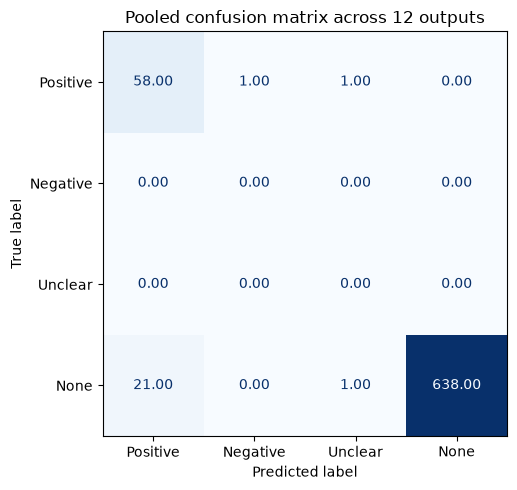

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

y_true = np.asarray(all_gt_labels).ravel()
y_pred = np.asarray(all_model_lables).ravel()  # note: labels, not lables

assert y_true.shape == y_pred.shape, (y_true.shape, y_pred.shape)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
    display_labels=['Positive','Negative','Unclear','None'],
    # normalize="true",       # optional: per-ground-truth-class recall
    cmap="Blues",
    ax=ax,
    values_format=".2f",
    colorbar=False,
)

ax.set_title("Pooled confusion matrix across 12 outputs")
plt.tight_layout()
plt.show()

# Log the confusion matrix figure to MLflow and close out the run
mlflow.log_figure(fig, "positive_examples_confusion_matrix.png")
mlflow.end_run()


## Negative examples

In [44]:
# Create a dedicated MLflow experiment + run for the "negative examples" evaluation
NEG_EXPERIMENT_NAME = "SDOH_Negative_Examples_Evaluation"
NEG_RUN_NAME = f"negative_examples_{'OneDomain' if not config.all_at_once else 'AllAtOnce'}{'WithEvidence' if config.add_evidence else ''}_run_{config.model_name}_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}"

mlflow.set_experiment(NEG_EXPERIMENT_NAME)
neg_run = mlflow.start_run(run_name=NEG_RUN_NAME)

print("Experiment name:", NEG_EXPERIMENT_NAME)
print("Run name:", NEG_RUN_NAME)
print("Run ID:", neg_run.info.run_id)

mlflow.log_param("model_id", getattr(config, "model_id", None))
mlflow.log_param("prompt_strategy", "all_at_once" if config.all_at_once else "per_domain")
mlflow.log_param("num_neg_datasets", len(loaded_datasets_neg))


Experiment name: SDOH_Negative_Examples_Evaluation
Run name: negative_examples_AllAtOnceWithEvidence_run_meta-llama3-1-8b-instruct-v1-0_20260915_163740
Run ID: 040e90216b994ae3a8863dc8c3641313


12

In [45]:
def create_gt_neg_label(idx, val = None):
    assert val is not None, "val cannot be none"
    gt = [3]*12
    gt[idx]= val
    return gt


In [46]:
all_gt_labels_neg = []
all_model_lables_neg = []

for label_idx, (key,items) in tqdm(enumerate(loaded_datasets_neg.items())):
    for note in items:

        gt_label = create_gt_neg_label(label_idx,val = 1)
        if config.all_at_once:
            label_json = ast.literal_eval(run_prompt(build_prompt(note, prompt = prompt_config.all_at_once)))
            prediction_label = [config.label_mapping[item["label"]] for item in label_json.values()]
        else:
            each_note_label = []
            for key, prompt in sdoh_prompts.items():
                try:
                    out = run_prompt(build_prompt(note, prompt = prompt))
                    each_note_label.append(ast.literal_eval(out))
                except:
                    print(out)
                    print("#####")
                    print(build_prompt(note, prompt = prompt))
                    print("####")
                    print(note)
                    print(asd)
            dict_labels = {key: value for item in json.loads(json.dumps(each_note_label, indent=2)) for key, value in item.items()}
            prediction_label = [config.label_mapping[item["label"]] for item in dict_labels.values()]


        all_gt_labels_neg.append(gt_label)
        all_model_lables_neg.append(prediction_label)


# Log basic run info to MLflow
mlflow.log_metric("num_examples_evaluated", len(all_gt_labels_neg))


0it [00:00, ?it/s][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
0it [00:09, ?it/s]


SyntaxError: invalid syntax (<unknown>, line 1)

In [ ]:
y_true = np.asarray(all_gt_labels_neg).ravel()
y_pred = np.asarray(all_model_lables_neg).ravel()

assert y_true.shape == y_pred.shape
assert set(np.unique(y_true)).issubset({0, 1, 2, 3})
assert set(np.unique(y_pred)).issubset({0, 1, 2, 3})

report_dict = classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
    target_names=["Positive", "Negative", "Unclear", "None"],
    zero_division=0,
    digits=4,
    output_dict=True,
)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=["Positive", "Negative", "Unclear", "None"],
        zero_division=0,
        digits=4,
    )
)

# Log the classification report to MLflow (as a JSON artifact + per-class metrics)
mlflow.log_dict(report_dict, "negative_examples_classification_report.json")

for cls_name, metrics_dict in report_dict.items():
    if isinstance(metrics_dict, dict):
        safe_name = cls_name.replace(" ", "_")
        for metric_name, metric_value in metrics_dict.items():
            mlflow.log_metric(f"{safe_name}_{metric_name}", metric_value)
    else:
        mlflow.log_metric(cls_name, metrics_dict)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

y_true = np.asarray(all_gt_labels_neg).ravel()
y_pred = np.asarray(all_model_lables_neg).ravel()

assert y_true.shape == y_pred.shape, (y_true.shape, y_pred.shape)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
    display_labels=['Positive','Negative','Unclear','None'],
    # normalize="true",       # optional: per-ground-truth-class recall
    cmap="Blues",
    ax=ax,
    values_format=".2f",
    colorbar=False,
)

ax.set_title("Pooled confusion matrix across 12 outputs (negative examples)")
plt.tight_layout()
plt.show()

# Log the confusion matrix figure to MLflow and close out the run
mlflow.log_figure(fig, "negative_examples_confusion_matrix.png")
mlflow.end_run()


## Unclear examples

In [30]:
# Create a dedicated MLflow experiment + run for the "unclear examples" evaluation
UNCLEAR_EXPERIMENT_NAME = "SDOH_Unclear_Examples_Evaluation"
UNCLEAR_RUN_NAME = f"unclear_examples_{'OneDomain' if not config.all_at_once else 'AllAtOnce'}{'WithEvidence' if config.add_evidence else ''}_run_{config.model_name}_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}"

mlflow.set_experiment(UNCLEAR_EXPERIMENT_NAME)
unclear_run = mlflow.start_run(run_name=UNCLEAR_RUN_NAME)

print("Experiment name:", UNCLEAR_EXPERIMENT_NAME)
print("Run name:", UNCLEAR_RUN_NAME)
print("Run ID:", unclear_run.info.run_id)

mlflow.log_param("model_id", getattr(config, "model_id", None))
mlflow.log_param("prompt_strategy", "all_at_once" if config.all_at_once else "per_domain")
mlflow.log_param("num_unclear_datasets", len(loaded_datasets_unclear))


Experiment name: SDOH_Unclear_Examples_Evaluation
Run name: unclear_examples_AllAtOnceWithEvidence_run_meta-llama3-1-8b-instruct-v1-0_20260915_154119
Run ID: 8150327ab50849e992b74700205a25b4


12

In [31]:
def create_gt_unclear_label(idx, val = None):
    assert val is not None, "val cannot be none"
    gt = [3]*12
    gt[idx]= val
    return gt


In [33]:
all_gt_labels_unclear = []
all_model_lables_unclear = []

for label_idx, (key,items) in tqdm(enumerate(loaded_datasets_unclear.items())):
    for note in items:

        gt_label = create_gt_unclear_label(label_idx,val = 2)
        if config.all_at_once:
            label_json = ast.literal_eval(extract_schema_dict(run_prompt(build_prompt(note, prompt = prompt_config.all_at_once))))
            prediction_label = [config.label_mapping[item["label"]] for item in label_json.values()]
        else:
            each_note_label = []
            for key, prompt in sdoh_prompts.items():
                try:
                    out = run_prompt(build_prompt(note, prompt = prompt))
                    each_note_label.append(ast.literal_eval(extract_schema_dict(out)))
                except:
                    print(out)
                    print("#####")
                    print(build_prompt(note, prompt = prompt))
                    print("####")
                    print(note)
                    print(asd)
            dict_labels = {key: value for item in json.loads(json.dumps(each_note_label, indent=2)) for key, value in item.items()}
            prediction_label = [config.label_mapping[item["label"]] for item in dict_labels.values()]


        all_gt_labels_unclear.append(gt_label)
        all_model_lables_unclear.append(prediction_label)


# Log basic run info to MLflow
mlflow.log_metric("num_examples_evaluated", len(all_gt_labels_unclear))


0it [00:00, ?it/s][transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=700) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information

In [34]:
y_true = np.asarray(all_gt_labels_unclear).ravel()
y_pred = np.asarray(all_model_lables_unclear).ravel()

assert y_true.shape == y_pred.shape
assert set(np.unique(y_true)).issubset({0, 1, 2, 3})
assert set(np.unique(y_pred)).issubset({0, 1, 2, 3})

report_dict = classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
    target_names=["Positive", "Negative", "Unclear", "None"],
    zero_division=0,
    digits=4,
    output_dict=True,
)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=["Positive", "Negative", "Unclear", "None"],
        zero_division=0,
        digits=4,
    )
)

# Log the classification report to MLflow (as a JSON artifact + per-class metrics)
mlflow.log_dict(report_dict, "unclear_examples_classification_report.json")

for cls_name, metrics_dict in report_dict.items():
    if isinstance(metrics_dict, dict):
        safe_name = cls_name.replace(" ", "_")
        for metric_name, metric_value in metrics_dict.items():
            mlflow.log_metric(f"{safe_name}_{metric_name}", metric_value)
    else:
        mlflow.log_metric(cls_name, metrics_dict)


              precision    recall  f1-score   support

    Positive     0.0000    0.0000    0.0000         0
    Negative     0.0000    0.0000    0.0000         0
     Unclear     0.6866    0.7667    0.7244        60
        None     0.9984    0.9636    0.9807       660

    accuracy                         0.9472       720
   macro avg     0.4212    0.4326    0.4263       720
weighted avg     0.9724    0.9472    0.9594       720



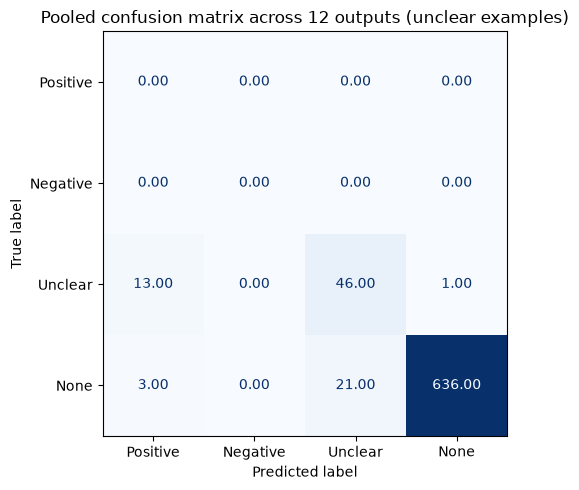

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

y_true = np.asarray(all_gt_labels_unclear).ravel()
y_pred = np.asarray(all_model_lables_unclear).ravel()

assert y_true.shape == y_pred.shape, (y_true.shape, y_pred.shape)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
    display_labels=['Positive','Negative','Unclear','None'],
    # normalize="true",       # optional: per-ground-truth-class recall
    cmap="Blues",
    ax=ax,
    values_format=".2f",
    colorbar=False,
)

ax.set_title("Pooled confusion matrix across 12 outputs (unclear examples)")
plt.tight_layout()
plt.show()

# Log the confusion matrix figure to MLflow and close out the run
mlflow.log_figure(fig, "unclear_examples_confusion_matrix.png")
mlflow.end_run()


In [24]:
from itertools import chain
all_notes = list(chain.from_iterable(list(loaded_datasets_unclear.values())))

for i in range(len(all_gt_labels_unclear)):
    if all_model_lables_unclear[i] != all_gt_labels_unclear[i]:
        print("Model label: ", all_model_lables_unclear[i])
        print("GT label: :", all_gt_labels_unclear[i])

        print("Note:", all_notes[i])
        print("\n\n\n")
        


Model label:  [3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3]
GT label: : [3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3]
Note: Pt is a 58 y/o M presenting for routine f/u of HTN and DM2. BP 138/82, A1c 7.2%. Medications reviewed and refilled. Patient mentioned he used to work in construction but unclear if currently employed or seeking work. Will continue current regimen, RTC 3 months.




Model label:  [3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3]
GT label: : [3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3]
Note: SUBJECTIVE: 45 y/o F here for annual wellness exam. Reports feeling well overall. No acute complaints. PMH: hypothyroidism, GERD. Social hx: patient states she had a job previously but did not clarify current work status. Vitals WNL. PLAN: Continue levothyroxine 75 mcg daily, omeprazole 20 mg daily. Labs ordered: TSH, lipid panel. Follow up in 12 months or sooner if concerns arise.




Model label:  [3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3]
GT label: : [3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3]
Note: Encounter Note
Patient: 50 

In [ ]:
    # "child_family_care",
    # "education",
    # "employment",
    # "financial_strain",
    # "food_insecurity",
    # "housing_instability",
    # "housing_quality",
    # "relationship_safety",
    # "social_isolation",
    # "stress",
    # "transportation",
    # "utilities",